---

# Heart Disease Prediction with Ensemble Methods

Ensemble methods combine multiple weak learners into a single stronger model. Rather than relying on a single decision tree, ensemble methods aggregate predictions from many trees to reduce variance, bias, or both.

In this notebook we explore two popular ensemble approaches:

- **Random Forest** — builds many decision trees on random subsets of the data and features, then averages their predictions
- **Gradient Boosting** — builds trees sequentially where each tree corrects the errors of the previous one

We apply both methods to the Heart Disease dataset to predict whether a patient has heart disease based on clinical measurements.

---

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn ensemble methods and tools
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

---

## Loading and Exploring the Data

---

In [2]:
# Load the Heart Disease dataset
df = pd.read_csv("heart_disease.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Check for missing values and class distribution
print(df.info())
print()
print("Class distribution:")
print(df['target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Class distribution:
target
1    165
0    138
Name: count, dtype: int64


---

## Defining Features and Target

---

In [4]:
# Separate features and target
X = df.drop(columns='target').values
y = df['target'].values

print("Feature matrix shape:", X.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (303, 13)
Class distribution: {np.int64(0): np.int64(138), np.int64(1): np.int64(165)}


---

## Splitting and Scaling the Data

---

In [5]:
# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (242, 13)
Test set size: (61, 13)


---

## Random Forest

Random Forest builds many decision trees on random subsets of the data and features, then takes a majority vote across all trees for the final prediction. This reduces overfitting compared to a single decision tree.

---

In [6]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Heart Disease']))

Random Forest Results:
               precision    recall  f1-score   support

   No Disease       0.83      0.83      0.83        29
Heart Disease       0.84      0.84      0.84        32

     accuracy                           0.84        61
    macro avg       0.84      0.84      0.84        61
 weighted avg       0.84      0.84      0.84        61



---

## Gradient Boosting

Gradient Boosting builds trees sequentially where each tree focuses on correcting the errors of the previous one. It tends to achieve higher accuracy than Random Forest but is slower to train.

---

In [9]:
# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

print("Gradient Boosting Results:")
print(classification_report(y_test, y_pred_gb, target_names=['No Disease', 'Heart Disease']))

Gradient Boosting Results:
               precision    recall  f1-score   support

   No Disease       0.77      0.79      0.78        29
Heart Disease       0.81      0.78      0.79        32

     accuracy                           0.79        61
    macro avg       0.79      0.79      0.79        61
 weighted avg       0.79      0.79      0.79        61



---

## Comparing the Models

---

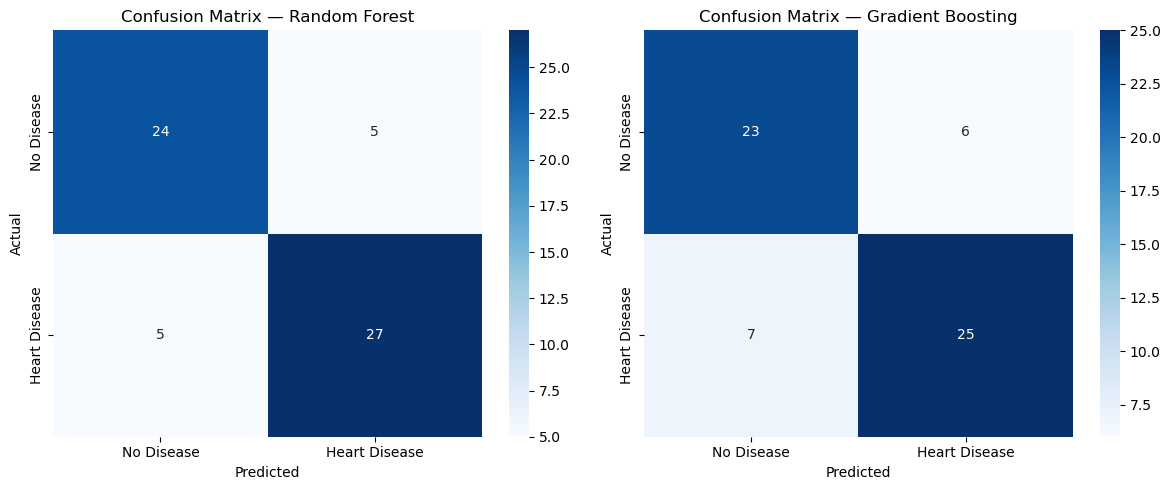

In [10]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_rf, y_pred_gb],
                              ['Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {title}")

plt.tight_layout()
plt.show()

---

## Feature Importance

Both models provide feature importance scores. Let's compare which features each model considers most important for predicting heart disease.

---

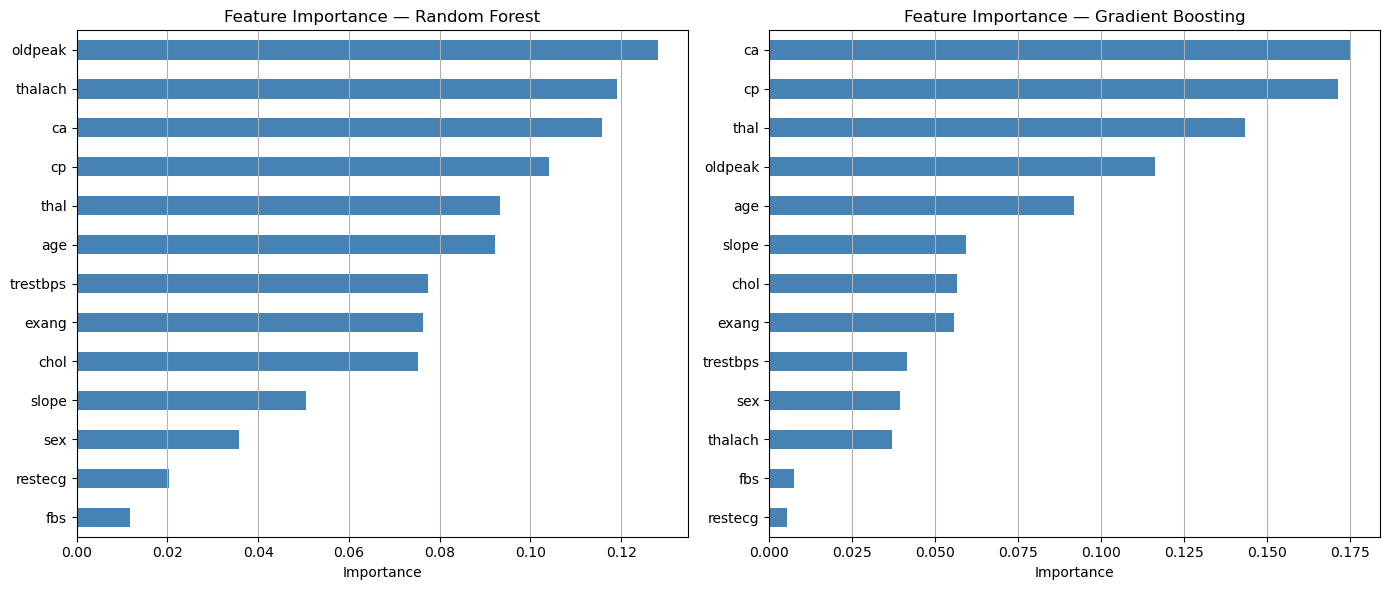

In [11]:
# Get feature names
feature_names = df.drop(columns='target').columns.tolist()

# Plot feature importances for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in zip(axes,
                              [rf, gb],
                              ['Random Forest', 'Gradient Boosting']):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values()
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f"Feature Importance — {title}")
    ax.set_xlabel("Importance")
    ax.grid(True, axis='x')

plt.tight_layout()
plt.show()

---

## Summary

In this notebook we applied two ensemble methods to predict heart disease from clinical measurements. Random Forest achieved 84% accuracy while Gradient Boosting achieved 79%.

Key takeaways:
- Random Forest reduces overfitting by averaging predictions across many trees trained on random subsets
- Gradient Boosting builds trees sequentially to correct previous errors, often achieving higher accuracy but at the cost of training speed
- Both methods provide feature importance scores — chest pain type (cp) and maximum heart rate (thalach) were consistently the most important features
- Ensemble methods almost always outperform single decision trees by reducing variance and bias

---